# **Anomalous Data Analysis Using Transformer-Based Reconstruction and Clustering**

In this notebook, we perform a systematic analysis of tabular data with the following pipeline:

- **Transformer-based Data Reconstruction:**  
  A transformer autoencoder is trained to reconstruct tabular data, learning the underlying structure of known background events. This helps identify anomalous (out-of-distribution) data through higher reconstruction error, as the model will struggle to reconstruct patterns it has never seen.

- **Masked Tabular Data Handling:**  
  We employ a masked reconstruction strategy, where parts of the data are systematically occluded during training, encouraging the transformer to learn meaningful latent representations and robustly impute missing or corrupted values.

- **Anomalous Data Filtering:**  
  After training the reconstruction model on background (normal) data, we compute reconstruction losses for the entire dataset. Points with high reconstruction loss are flagged as anomalous candidates.

- **Clustering for Anomaly Exploration:**  
  The filtered anomalous data is further analyzed using Gower distance (to handle mixed data types) and dimensionality reduction with UMAP. Finally, HDBSCAN clustering is applied to discover potential subgroups or patterns within the anomalies, facilitating deeper insights into their structure.

- **Root File Integration with TMVA Batching:**  
  To efficiently handle ROOT files from high-energy physics experiments, we create a TensorFlow batch generator based on TMVA preprocessing pipelines. This enables direct ingestion of ROOT files into the ML training process without intermediate conversions, streamlining the workflow for large-scale physics datasets.

The overall framework enables:
- unsupervised anomaly detection,  
- robust data reconstruction,  
- and interpretable clustering of anomalies,  

which together provide a powerful toolset for discovering novel patterns in complex tabular datasets, such as those from high-energy physics experiments.



### Imports

- **ROOT**: a data analysis framework widely used in high-energy physics for handling ROOT files and performing complex statistical analysis  
- **matplotlib.pyplot**: standard Python plotting library for data visualization  
- **numpy**: numerical computing with arrays and mathematical functions  
- **pandas**: tabular data analysis with DataFrames  
- **tensorflow** (and keras modules): for building and training deep learning models  
  - `layers, Model, Sequential`: neural network layers and model structures
  - `losses, metrics, optimizers, models`: core tools for compiling and evaluating models
  - `LeakyReLU, Input, Dense, LayerNormalization, Dropout, Lambda, Concatenate, Layer, BatchNormalization`: a wide variety of layers and activations to build custom neural networks
  - `Adam`: a popular optimizer for faster convergence
- **softmax** from `tensorflow.nn`: activation function often used for multi-class classification
- **scikit-learn**:
  - `train_test_split`: splitting data for training/testing
  - `MinMaxScaler`: normalizes features to a 0–1 range
  - `Pipeline`: chains multiple preprocessing steps together

These imports together set up a powerful environment for:
- reading and handling ROOT-based physics data
- preprocessing it
- building advanced deep learning pipelines with TensorFlow/Keras
- visualizing and analyzing results with standard Python plotting tools


In [3]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import pandas as pdimport tensorflow as tf
from tensorflow.keras import layers, Model , Sequential, losses ,metrics, optimizers, models
from tensorflow.keras.layers import LeakyReLU, Input, Dense, LayerNormalization, Dropout,Lambda, Concatenate, Layer, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.nn import softmax
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

2025-07-05 00:28:17.533319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751668097.548429     356 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751668097.553008     356 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-05 00:28:17.571938: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Variable Definitions and Checks

In this section, we define and organize the variables used in the analysis:

- **`column_order`**:  
  A long, explicit list describing the ordering of all physics variables expected in the dataset. It includes kinematic properties (e.g., jet transverse momenta `jet*_pt`), angular variables (`phi`, `eta`), invariant masses (e.g., `Mll`, `Mjjll`), event-level variables (e.g., `Event_density`, `MET_cal1_e`), and various counts (like `Nleptons`, `Nbjets`, etc.). This list is used to keep track of the entire data feature space in a consistent order.

- **`type1_branches`**:  
  A smaller list selecting the *input features* for the first group of variables, mostly related to the transverse momentum and mass of leading jets, photons, and some high-level variables (like HT, invariant masses, and missing transverse energy).

- **`type2_branches`**:  
  Another smaller list, in this case holding the `Nleptons` variable, to capture lepton counts.

- **`branches`**:  
  Combines `type1_branches` and `type2_branches` — this is essentially the **full input feature set** for the model.

- **`targets`**:  
  A large list of physics variables that serve as **output targets** for prediction, including the remainder of the variables in `column_order` that are not present in `branches`. These cover secondary jet properties, photon properties, sub-leading objects, and event-level derived quantities.

---

#### Consistency Check
- The code then prints the lengths of:
  - `branches` (input variables)
  - `column_order` (full list of variables to keep track of)
  - `targets` (variables to be predicted)

- It also checks if there are any variables defined in `column_order` that are missing from **both** the `branches` and the `targets`. These variables are printed to help the user spot potential issues in data consistency or missing columns that might cause training errors later.

This step is crucial for **physics-based machine learning pipelines** to verify:
- feature engineering consistency
- training/validation feature completeness
- prevention of misalignment between input/output variables


In [4]:
column_order =[ 'jet1_pt', 'jet2_pt', 'jet3_pt', 'jet4_pt', 'photon1_pt', 'photon2_pt', 'UFO_jet1_pt', 'UFO_jet2_pt','Large_RJet1_pt','Large_RJet2_pt', 'HT', 'lepton1_pt',
               'jet1_phi', 'jet2_phi', 'jet3_phi', 'jet4_phi', 'photon1_phi','photon2_phi','UFO_jet1_phi', 'UFO_jet2_phi',  'Large_RJet1_phi', 'Large_RJet2_phi', 'Egamma_cluster1_calPhi','Egamma_cluster2_calPhi', 'lepton1_phi',
               'jet1_eta', 'jet2_eta', 'jet3_eta', 'jet4_eta', 'photon1_eta','photon2_eta','UFO_jet1_eta', 'UFO_jet2_eta',  'Large_RJet1_eta', 'Large_RJet2_eta', 'Egamma_cluster1_calEta', 'Egamma_cluster2_calEta', 'lepton1_eta',
               'jet1_m', 'jet2_m', 'jet3_m', 'jet4_m', 'UFO_jet1_m' ,'UFO_jet2_m','Large_RJet1_m','Large_RJet2_m', 'Egamma_cluster1_calM', 'Egamma_cluster2_calM', 
               'mj1j2', 'mj1j3', 'mj1j4', 'mj2j3', 'mj2j4', 'mj3j4','mb1b2',"Mgg", "Mggg", "Mgggg", "Mll", "Mlll", "Mllll", "MT", "MTgg", "mj1l", "mjjj", "mjjll",
               "Event_density", 'MET_cal1_e', 'photon1_topoetcone20', 'photon1_topoetcone40', 'photon2_topoetcone20', 'photon2_topoetcone40', 'Egamma_cluster1_calE','Egamma_cluster2_calE',
               'delta_Rj1j2', 'delta_Rj1j3', 'delta_Rj1j4', 'delta_Rj2j3', 'delta_Rj2j4', 'delta_Rj3j4', "delta_Rj1l1","delta_Rj2l1","delta_Rj1g1","delta_Rj2g1",
               'MET1_mpx', 'MET1_mpy', 'MET_cal1_py', 'MET_cal1_px', 'MET_cal1_pz','MET_cal2_py', 'MET_cal2_px', 'MET_cal2_pz',
               'jet1_Width', 'jet2_Width', 'jet3_Width', 'jet4_Width', 'jet1_EMFrac', 'jet2_EMFrac', 'jet3_EMFrac', 'jet4_EMFrac', 
               'Nleptons', 'Nbjets','Nelectrons', 'Njets', 'Nmuons', 'Nphotons', 'Ngamma', 'NMET_cal',   
               "Runnumber", "Event_weight"]
type1_branches  = ['jet1_pt', 'jet2_pt', 'jet3_pt','photon1_pt', 'UFO_jet1_pt', 'Large_RJet1_pt','HT','jet1_m', 'UFO_jet1_m' ,'Large_RJet1_m','mj1j2', 'mj1j3','mj2j3','MET_cal1_e','Egamma_cluster1_calE']
type2_branches  = ['Nleptons']
branches = type1_branches  + type2_branches 

targets =[  'jet4_pt',  'photon2_pt',  'UFO_jet2_pt','Large_RJet2_pt',  'lepton1_pt',
               'jet1_phi', 'jet2_phi', 'jet3_phi', 'jet4_phi', 'photon1_phi','photon2_phi','UFO_jet1_phi', 'UFO_jet2_phi',  'Large_RJet1_phi', 'Large_RJet2_phi', 'Egamma_cluster1_calPhi','Egamma_cluster2_calPhi', 'lepton1_phi',
               'jet1_eta', 'jet2_eta', 'jet3_eta', 'jet4_eta', 'photon1_eta','photon2_eta','UFO_jet1_eta', 'UFO_jet2_eta',  'Large_RJet1_eta', 'Large_RJet2_eta', 'Egamma_cluster1_calEta', 'Egamma_cluster2_calEta', 'lepton1_eta',
               'jet2_m', 'jet3_m', 'jet4_m', 'UFO_jet2_m','Large_RJet2_m', 'Egamma_cluster1_calM', 'Egamma_cluster2_calM', 
                'mj1j4',  'mj2j4', 'mj3j4','mb1b2',"Mgg", "Mggg", "Mgggg", "Mll", "Mlll", "Mllll", "MT", "MTgg", "mj1l", "mjjj", "mjjll",
               "Event_density",  'photon1_topoetcone20', 'photon1_topoetcone40', 'photon2_topoetcone20', 'photon2_topoetcone40', 'Egamma_cluster2_calE',
               'delta_Rj1j2', 'delta_Rj1j3', 'delta_Rj1j4', 'delta_Rj2j3', 'delta_Rj2j4', 'delta_Rj3j4', "delta_Rj1l1","delta_Rj2l1","delta_Rj1g1","delta_Rj2g1",
               'MET1_mpx', 'MET1_mpy', 'MET_cal1_py', 'MET_cal1_px', 'MET_cal1_pz','MET_cal2_py', 'MET_cal2_px', 'MET_cal2_pz',
               'jet1_Width', 'jet2_Width', 'jet3_Width', 'jet4_Width', 'jet1_EMFrac', 'jet2_EMFrac', 'jet3_EMFrac', 'jet4_EMFrac', 
                'Nbjets','Nelectrons', 'Njets', 'Nmuons', 'Nphotons', 'Ngamma', 'NMET_cal',   
               "Runnumber", "Event_weight"]


print(len(branches),len(column_order),len(targets))
missing_in_both = [v for v in column_order if v not in branches and v not in targets]

print(f"Variables in column_order missing in both branches and targets ({len(missing_in_both)}):")
for v in missing_in_both:
    print(v)

16 110 94
Variables in column_order missing in both branches and targets (0):


### ROOT DataFrame Setup and Entry Counting

- **`tree_name`**: Specifies the name of the ROOT TTree to load from the file.
- **`verified_file_names`**: List of ROOT files to read from, supports remote paths with the `root://` protocol.
- **`ROOT.RDataFrame`**: High-level ROOT interface to efficiently load and process large datasets in a lazy evaluation manner.
- **`rdf.Count()`**: Action that counts the total number of entries (events) in the specified TTree.
- **`GetValue()`**: Retrieves the computed count as an integer.

This approach allows checking the dataset size before starting any data processing or machine learning tasks.


In [5]:
# --- ROOT settings ---
tree_name = "myTree"

batch_size = 512
chunk_size = 100000
validation_split = 0.3
verified_file_names =['root://eosuser.cern.ch//eos/user/a/asradhak/SWAN_projects/ml_training/training/run2_.root']
# --- Load RDataFrame ---
rdf = ROOT.RDataFrame(tree_name, verified_file_names)

num_entries = rdf.Count().GetValue()
print(num_entries)

2100233


### Creating TensorFlow Datasets from ROOT RDataFrame

- `ROOT.TMVA.Experimental.CreateTFDatasets` converts the ROOT RDataFrame (`rdf`) into TensorFlow datasets for training and validation.
- Parameters:
  - `batch_size`: Number of samples per batch during training.
  - `chunk_size`: Number of entries read at a time from ROOT to optimize memory and I/O.
  - `validation_split`: Fraction of data reserved for validation.
  - `shuffle=True`: Randomly shuffles the data before batching.
  - `target`: Specifies the target variables (labels) for supervised learning.
- Returns two datasets:
  - `ds_train_`: Training dataset including both features and targets.
  - `ds_valid_`: Validation dataset including both features and targets.
- `input_columns`: List of feature column names used for training.
- `num_features`: Number of input features.
- `.map(lambda x, y: x)`: Maps datasets to extract only the feature tensors, ignoring targets. This is useful when you want to use features alone for tasks like autoencoding.

This pipeline bridges ROOT data and TensorFlow, enabling efficient ML workflows on ROOT files.


In [6]:
ds_train_, ds_valid_ = ROOT.TMVA.Experimental.CreateTFDatasets(
    rdf,
    batch_size=batch_size,
    chunk_size=chunk_size,
    validation_split=validation_split,
    shuffle=True,
    target= targets,
)
 
# Get a list of the columns used for training
input_columns = ds_train_.train_columns
num_features = len(input_columns)

ds_train = ds_train_.map(lambda x, y: x)
ds_valid = ds_valid_.map(lambda x, y: x)
ds_train 

I0000 00:00:1751668158.583730     356 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38550 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:00:06.0, compute capability: 8.0


### Custom Transformer Components in TensorFlow

- **MultiHeadAttention Layer**  
  Implements multi-head self-attention with:
  - Learnable query, key, value projections (`Dense` layers with L2 regularization).
  - Splitting inputs into multiple heads for parallel attention.
  - Scaled dot-product attention with optional masking.
  - Output projection back to the original model dimension.

- **CustomLayerNormalization Layer**  
  Normalizes inputs per feature dimension with trainable scale (`gamma`) and shift (`beta`) parameters, using a numerically stable formula.

- **CustomLinear Layer**  
  A fully connected linear layer with custom L1 and L2 weight regularization (weight decay) applied to the kernel weights.

- **AdvancedFeedForward Layer**  
  A feed-forward network with:
  - Two `CustomLinear` layers.
  - Leaky ReLU activation (with customizable negative slope `alpha_rt`).
  - Dropout for regularization.
  - Batch normalization with a residual connection.

This modular design supports building robust transformer-based architectures with explicit regularization and normalization controls for improved training stability and generalization.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers

class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        self.wq = layers.Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-4), bias_regularizer=tf.keras.regularizers.l2(1e-4))
        self.wk = layers.Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-4), bias_regularizer=tf.keras.regularizers.l2(1e-4))
        self.wv = layers.Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-4), bias_regularizer=tf.keras.regularizers.l2(1e-4))
        self.dense = layers.Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-4), bias_regularizer=tf.keras.regularizers.l2(1e-4))

    def split_heads(self, x, batch_size):
        # x: (batch_size, seq_len, d_model)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))  # (B, S, H, D_head)
        return tf.transpose(x, perm=[0, 2, 1, 3])  # (B, H, S, D_head)

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)  # (B, H, S_q, S_k)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            # mask should be broadcastable to (B, H, S_q, S_k)
            # typically mask ∈ {0, 1}; convert 0s to large negative numbers for masking
            mask = tf.cast(mask, tf.float32)
            scaled_logits += (1.0 - mask) * -1e9

        attention_weights = tf.nn.softmax(scaled_logits, axis=-1)  # (B, H, S_q, S_k)
        output = tf.matmul(attention_weights, v)  # (B, H, S_q, D)

        return output, attention_weights

    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (B, S_q, D)
        k = self.wk(k)  # (B, S_k, D)
        v = self.wv(v)  # (B, S_v, D)

        q = self.split_heads(q, batch_size)  # (B, H, S_q, D_head)
        k = self.split_heads(k, batch_size)  # (B, H, S_k, D_head)
        v = self.split_heads(v, batch_size)  # (B, H, S_v, D_head)

        # Let broadcasting handle the mask shape as in tf.keras.layers.MultiHeadAttention
        attention_output, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)

        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])  # (B, S_q, H, D_head)
        concat_attention = tf.reshape(attention_output, (batch_size, -1, self.d_model))  # (B, S_q, D)

        output = self.dense(concat_attention)  # (B, S_q, D)
        return output


# Custom Layer Normalization
class CustomLayerNormalization(layers.Layer):
    def __init__(self, epsilon=1e-6):
        super(CustomLayerNormalization, self).__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(input_shape[-1],), initializer="ones", trainable=True)
        self.beta = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta


# Custom Linear Layer with Weight Decay
class CustomLinear(layers.Layer):
    def __init__(self, out_features, weight_decay=0.0001):
        super(CustomLinear, self).__init__()
        self.out_features = out_features
        self.weight_decay = weight_decay

    def build(self, input_shape):
        self.weight = self.add_weight(shape=(input_shape[-1], self.out_features),
                                      initializer="random_normal",
                                      regularizer=tf.keras.regularizers.l1_l2(self.weight_decay,self.weight_decay),
                                      trainable=True)
        self.bias = self.add_weight(shape=(self.out_features,), initializer="zeros", trainable=True)

    def call(self, inputs):
        return tf.matmul(inputs, self.weight) + self.bias


# Advanced Feed Forward Layer
class AdvancedFeedForward(layers.Layer):
    def __init__(self, dff, d_model, rate, weight_decay, alpha_rt):
        super(AdvancedFeedForward, self).__init__()
        self.dense1 = CustomLinear(dff, weight_decay)
        self.dense2 = CustomLinear(d_model, weight_decay)
        self.dropout = layers.Dropout(rate)
        self.layernorm = layers.BatchNormalization()
        self.alpha_rt = alpha_rt

    def call(self, x, training):
        x = self.dense1(x)
        x = tf.nn.leaky_relu(x, alpha=self.alpha_rt)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        return self.layernorm(x + self.dropout(x, training=training))
        


### Notes on Tabular Transformer Code

- **Mask Generation:**  
  - `generate_mask(x)` creates a binary mask from input `x` by marking entries not equal to `-99.0` as valid (`1`), missing as `0`.  
  - `generate_training_mask(mask, dropout_rate)` randomly drops observed features during training (dropout), simulating missing data and improving robustness.

- **Masked Multi-Head Attention:**  
  - `MaskedMultiHeadAttention` applies the standard `MultiHeadAttention` layer with a boolean mask expanded to shape `[batch, 1, 1, seq_len]` to avoid attending to missing tokens/features.

- **Transformer Blocks:**  
  - Encoder and decoder blocks use masked multi-head attention, feed-forward networks, normalization (LayerNorm or BatchNorm), and dropout for regularization.  
  - The decoder uses cross-attention over the encoder output.

- **Model Architecture:**  
  - Input features are split into groups of different categorical sizes (`type_sizes`) and embedded independently with dense layers before concatenation.  
  - The transformer encoder and decoder operate on these embeddings.  
  - Separate dense output layers decode each feature group.  
  - Final outputs are concatenated and masked with the original mask (not the dropped training mask) to zero-out missing features in predictions.

- **Loss Function:**  
  - A custom masked MSE loss computes reconstruction error only on observed features, ignoring missing ones.

- **Usage of Masks:**  
  - The training mask simulates missingness to encourage the model to learn robust imputation.  
  - The original mask is used to evaluate loss and mask final outputs so that missing features do not affect loss or predictions.

This approach enables robust reconstruction and imputation of tabular data with heterogeneous feature types and missing values.


In [12]:

def generate_training_mask(mask, dropout_rate=0.2):
    random_vals = tf.random.uniform(shape=tf.shape(mask))
    training_mask = tf.where(
        mask == 1,
        tf.cast(random_vals > dropout_rate, tf.float32),
        0.0
    )
    return training_mask

def generate_mask(x):
    mask =tf.cast(tf.not_equal(x, -99.0), tf.float32)
    return mask


# === Masked Multihead Self-Attention ===
class MaskedMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = MultiHeadAttention( d_model, num_heads)
        self.num_heads = num_heads
    def call(self, x1,x2,x3, mask):
        attention_mask = tf.cast(mask[:, tf.newaxis, tf.newaxis, :], tf.float32)
        return self.mha(x1, x2, x3, attention_mask)


# === Transformer Encoder Block ===
class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff , rate, weight_decay, alpha_rt):
        super().__init__()
        self.att = MaskedMultiHeadAttention(d_model, num_heads)
        self.ffn = AdvancedFeedForward(dff, d_model, rate , weight_decay, alpha_rt)
        self.norm1 = layers.LayerNormalization(epsilon=1e-4)
        self.norm2 = layers.LayerNormalization(epsilon=1e-4)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
        
    def call(self, x, mask, training= None):
        attn_output = self.att(x,x,x, mask)
        x = self.norm1(x + self.dropout1(attn_output, training = training))
        ffn_output = self.ffn(x, training = training)
        return self.norm2(x + self.dropout2(ffn_output, training = training))

# === Transformer Decoder Block with Cross-Attention ===
class TransformerDecoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate, weight_decay, alpha_rt):
        super().__init__()
        self.att = MaskedMultiHeadAttention(d_model, num_heads)
        self.ffn = AdvancedFeedForward(dff, d_model, rate , weight_decay, alpha_rt)
        self.norm1 = layers.BatchNormalization(epsilon=1e-5)
        self.norm2 = layers.BatchNormalization(epsilon=1e-5)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, enc_output, mask, training= None):
        x = self.att(enc_output, enc_output,enc_output, mask)
        x = self.norm1(x + self.dropout1(x,training = training))
        ffn_output = self.ffn(x, training = training)
        return self.norm2(x + self.dropout2(ffn_output,training = training))

# === Encoder Wrapper ===
class Encoder(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, num_layers, rate, weight_decay, alpha_rt):
        super().__init__()
        self.layers = [TransformerEncoderBlock(d_model, num_heads, dff, rate, weight_decay, alpha_rt) for _ in range(num_layers)]
        self.num_layers = num_layers
        self.d_model = d_model
        self.dff = dff
        self.num_heads = num_heads
        self.rate =  rate
        self.weight_decay = weight_decay
        self.alpha_rt = alpha_rt
    def call(self, x, mask, training = None ):
        for layer in self.layers:
            x = layer(x, mask, training = training)
        return x

# === Decoder Wrapper ===
class Decoder(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, num_layers,  rate, weight_decay, alpha_rt):
        super().__init__()
        self.layers = [TransformerDecoderBlock(d_model, num_heads, dff,rate, weight_decay, alpha_rt) for _ in range(num_layers)]

    def call(self, x_emb, enc_output, self_mask, training = None):
        x = x_emb
        for layer in self.layers:
            x = layer(x, enc_output, self_mask, training = training)
        return x


# === Mask-aware MSE Loss ===
def masked_mse_loss(y_true, y_pred, mask):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.expand_dims(y_true, -1)

    mse = tf.abs(y_true - y_pred)
    mask_expanded = tf.expand_dims(mask, -1)
    mse_masked = mse * mask_expanded
    mask_sum = tf.reduce_sum(mask_expanded)
    mse_sum = tf.reduce_sum(mse_masked)
    return mse_sum / mask_sum

    
# === Full Tabular Transformer Model ===
class TabularTransformer(tf.keras.Model):
    def __init__(self,  d_model=64, num_heads=4, dff=128, num_layers=4, rate=0.5, weight_decay=1e-4, alpha_rt=0.05):
        super().__init__()
        self.encoder = Encoder(d_model, num_heads, dff, num_layers , rate, weight_decay, alpha_rt)
        self.decoder = Decoder(d_model, num_heads, dff, num_layers , rate, weight_decay, alpha_rt)
        
        self.type_sizes = [3,4,3,3,2,1]
        
        # Define independent embeddings for each type
        self.input1_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))
        self.input2_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))
        self.input3_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))
        self.input4_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))
        self.input5_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))
        self.input6_embedding = tf.keras.layers.Dense(d_model,kernel_regularizer=tf.keras.regularizers.l2(1e-5))

        # Output layers per group (same order)
        self.out1 = tf.keras.layers.Dense(1)
        self.out2 = tf.keras.layers.Dense(1)
        self.out3 = tf.keras.layers.Dense(1)
        self.out4 = tf.keras.layers.Dense(1)
        self.out5 = tf.keras.layers.Dense(1)
        self.out6 = tf.keras.layers.Dense(1)
        
    def get_config(self):
        config = super(TabularTransformer, self).get_config()
        config.update({
            'num_layers': self.encoder.num_layers,
            'd_model': self.encoder.d_model,
            'num_heads': self.encoder.num_heads,
            'dff': self.encoder.dff,
            'rate': self.encoder.rate,
            'weight_decay': self.encoder.weight_decay,
            'alpha_rt': self.encoder.alpha_rt
        })
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        # Extract and remove Keras-specific attributes before passing to __init__
        return cls(
            num_layers=config['num_layers'],
            d_model=config['d_model'],
            num_heads=config['num_heads'],
            dff=config['dff'],
            rate=config['rate'],
            weight_decay=config['weight_decay'],
            alpha_rt=config['alpha_rt'],            
        )        
    def call(self, x, training=None):
        
        x = tf.expand_dims(x, axis=-1)
        mask = generate_mask(x[..., 0])
        mask_train = generate_training_mask(mask)
        mask_expanded = tf.expand_dims(mask_train, -1)
        x = x * mask_expanded
        
        
        splits = tf.split(x, self.type_sizes, axis=1)

        # Apply each embedding separately
        emb1 = self.input1_embedding(splits[0])
        emb2 = self.input2_embedding(splits[1])
        emb3 = self.input3_embedding(splits[2])
        emb4 = self.input4_embedding(splits[3])
        emb5 = self.input5_embedding(splits[4])
        emb6 = self.input6_embedding(splits[5])
        # Concatenate all embeddings along variable dimension
        x_emb = tf.concat([emb1, emb2, emb3, emb4,emb5, emb6], axis=1)
        encoded = self.encoder(x_emb, mask_train, training=training)
        decoded = self.decoder(x_emb, encoded, mask_train, training=training)
        decoded_splits = tf.split(decoded, self.type_sizes, axis=1)

        out1 = self.out1(decoded_splits[0])
        out2 = self.out2(decoded_splits[1])
        out3 = self.out3(decoded_splits[2])
        out4 = self.out4(decoded_splits[3])
        out5 = self.out5(decoded_splits[4])
        out6 = self.out6(decoded_splits[5])

        # Concatenate all outputs
        output = tf.concat([out1, out2], axis=1)
        
        
        mask_expanded_ = tf.expand_dims(mask, -1)
        return output * mask_expanded_, mask

 



In [13]:


def val_step(x):
    x_pred, mask = model(x, training=False)
    loss = masked_mse_loss(x, x_pred, mask)
    return loss


@tf.function
def train_step(x):
    with tf.GradientTape() as tape:
        x_pred, mask = model(x)
        loss = masked_mse_loss(x, x_pred, mask)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

initial_lr = 1e-3

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

# Model, optimizer
model = TabularTransformer()
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Early stopping variables
best_val_loss = float('inf')
patience = 3
wait = 0

epochs = 15

for epoch in range(epochs):
    train_loss = 0.0
    val_loss = 0.0
    train_batches = 0
    val_batches = 0

    # Training loop
    for batch in ds_train:
        loss = train_step(batch)
        train_loss += loss
        train_batches += 1

    # Validation loop
    for val_batch in ds_valid:
        v_loss = val_step(val_batch)
        val_loss += v_loss
        val_batches += 1

    train_loss /= train_batches
    val_loss /= val_batches

    print(f"Epoch {epoch+1} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        #model.save_weights("best_model_weights.h5")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

# Load best model weights
#model.load_weights("best_model_weights.h5")


/cvmfs/sft.cern.ch/lcg/views/LCG_107_cuda/x86_64-el9-gcc11-opt/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'variable_48', 'variable_49', 'variable_50', 'variable_51', 'gamma', 'beta', 'gamma', 'beta', 'gamma', 'beta', 'kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'variable_52', 'variable_53', 'variable_54', 'variable_55', 'gamma', 'beta', 'gamma', 'beta', 'gamma', 'beta', 'kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'kernel', 'bias', 'variable_56', 'variable_57', 'variable_58', 'variable_59', 'gamma', 'beta', 'gamma', 'beta', 'gamma', 'beta'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 1 - Train Loss: 28.5191 | Val Loss: 21.3043
Epoch 2 - Train Loss: 21.0223 | Val Loss: 20.2520
Epoch 3 - Train Loss: 20.1113 | Val Loss: 19.5391
Epoch 4 - Train Loss: 19.5124 | Val Loss: 19.3150
Epoch 5 - Train Loss: 19.1015 | Val Loss: 18.7766
Epoch 6 - Train Loss: 18.8809 | Val Loss: 18.7704


KeyboardInterrupt: 

2025-07-05 00:59:48.827817: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
model.save("transformer_model1.keras")


In [ ]:
loaded_transformer = tf.keras.models.load_model('transformer_model1.keras', custom_objects={
    'TabularTransformer': TabularTransformer
})

### Note on ROOT File Processing and Reconstruction

The following Python code snippet processes multiple ROOT files using a TensorFlow model for reconstruction. For each ROOT file, it:

- Loads the data using `ROOT.RDataFrame`.
- Converts the data to TensorFlow datasets for batch processing.
- Runs the model to obtain reconstructed outputs and masks.
- Applies a mask-aware mean absolute error loss function (`RecoProb_`) to calculate reconstruction loss.
- Stores the results (losses, reconstructed data, and original inputs) in dictionaries keyed by the file's base name (filename without `.root`).

This structure enables organized handling and later analysis of reconstruction performance across multiple datasets.

The loss function `RecoProb_` handles masked values and replaces missing data marked by `-99.0` with zeros before computing errors.

Make sure the following variables are defined and accessible in your environment for the code to run correctly:
- `model` — The TensorFlow model used for reconstruction.
- `targets` — Target variables used for dataset creation.
- `branches` — Column names corresponding to input features.


In [ ]:

# === Loss function (mask-aware MSE) ===
def RecoProb_(y_true, y_pred, mask):
    # Cast both tensors to float32 before operations
    y_true_float = tf.cast(y_true, tf.float32)
    y_pred_float = tf.cast(y_pred, tf.float32)

    y_true_float = tf.where(y_true_float == -99.0, 0.0, y_true_float)
    y_pred_float = tf.where(y_pred_float == -99.0, 0.0, y_pred_float)
    
    y_true_float = tf.expand_dims(y_true_float, -1)
    
    mse = tf.abs(y_true_float - y_pred_float)
    mask_expanded = tf.expand_dims(mask, -1)
    mse_masked = mse * mask_expanded
    
    # Calculate mean over valid positions
    mask_sum = tf.reduce_sum(mask_expanded, axis = 1)
    mse_sum = tf.reduce_sum(mse_masked, axis = 1)
    
    return mse_sum / mask_sum
# === Loss function (mask-aware MSE) ===



# Load the dataframe


# We just need the features (inputs) for testing

    

def process_file(filepath):
    tree_name = "myTree"
    rdf2 = ROOT.RDataFrame(tree_name, filepath)

    # Optional check: skip empty trees
    if rdf2.Count().GetValue() == 0:
        print(f"[WARNING] Empty tree in file: {filepath}")
        return None, None, None

    ds_test = ROOT.TMVA.Experimental.CreateTFDatasets(
        rdf2,
        batch_size=10000,
        chunk_size=20000,
        validation_split=0.0,
        shuffle=True,
        target=targets,
    )

    try:
        for X_test_, y_true in ds_test.take(1):
            decoded, mask = model(X_test_, training=False)
            mask_expanded = tf.expand_dims(mask, -1)
            decoded = decoded* mask_expanded + (-99)*(1- mask_expanded)
            loss = RecoProb_(X_test_, decoded, mask)

            decoded_ = tf.squeeze(decoded, -1)
            reconstructed_x = pd.DataFrame(decoded_.numpy(), columns=branches)
            x_test = pd.DataFrame(X_test_.numpy(), columns=branches)
            losses_df = pd.DataFrame(loss.numpy(), columns=['mae_loss'])
            return losses_df, reconstructed_x, x_test

        print(f"[WARNING] No batches returned from dataset for: {filepath}")
        return None, None, None

    except Exception as e:
        print(f"[ERROR] Failed on file: {filepath}")
        print(f"Exception: {e}")
        return None, None, None


file_paths = [
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/LO_C1N2N1_GGMHinoZh50_800_noFilter_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/LO_C1N2_WZ_500p0_100p0_3L_2L7_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/LO_DM_4topscalar_p1000_c1_nonallhad_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/LO_TT_tN1_1200_200_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNLOPS_nnlo_30_ggH125_ZZ4l_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNLOPS_nnlo_30_ggH125_gamgam_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_Wprime_taunu_SSM3000_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_Zprime3000_tt_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_jetjet_JZ0WithSW_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_jetjet_JZ1WithSW_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_jetjet_JZ2WithSW_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_jetjet_JZ3WithSW_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF23LO_zprime3000_tt_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/NNPDF30_AZNLOCTEQ6L1_VBFH125_bb_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/SM_N2C1p_105_100_2L2MET75_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wenu_maxHTpTV2_CFilterBVeto_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wenu_maxHTpTV2_CVetoBVeto_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wmunu_maxHTpTV2_CFilterBVeto_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wmunu_maxHTpTV2_CVetoBVeto_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wtaunu_H_maxHTpTV2_BFilter_0.root",
    "/eos/user/a/asradhak/SWAN_projects/ml_training/data/root_test/Wtaunu_L_maxHTpTV2_CVetoBVeto_0.root",
    "root://eosuser.cern.ch//eos/user/a/asradhak/SWAN_projects/ml_training/training/run2.root",
]

# Create dictionaries to store the results
losses_dfs = {}
reconstructed_x = {}
x_test = {}
dataset = {}

# Process each ROOT file
for path in file_paths:
    # Use file name without extension as key
    key = path.split('/')[-1].replace('.root', '')
    
    # Call your ROOT processing function
    losses_dfs[key], reconstructed_x[key], x_test[key] = process_file(path)


### Plotting Reconstruction Loss Distributions

This code snippet plots the distribution of reconstruction losses (`mae_loss`) for different physics datasets:

- Loads loss DataFrames from previously computed results (`losses_dfs`).
- Groups background data (`run2`) and several signal samples (QCD, ggH → γγ, ggH → ZZ4l, VBF → bb, GGM HinoZh).
- Defines colors for each signal sample.
- Defines a function `plot_loss_data` that:
  - Plots the background loss distribution as a filled histogram with error bars.
  - Overlays signal loss distributions as step histograms.
  - Uses logarithmic scale on the y-axis.
  - Adds axis labels, grid ticks, and annotations indicating the dataset and energy scale.
  - Saves the plot as `'transformerloss_1.png'` and shows it.

This visualization helps compare the reconstruction loss behavior for background versus signal events, useful in anomaly detection and physics analysis contexts.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator

# assign dataframes from losses_dfs
run2_df = losses_dfs['run2']
qcd_df = losses_dfs['NNPDF23LO_jetjet_JZ0WithSW_0']
hgg_df = losses_dfs['NNLOPS_nnlo_30_ggH125_gamgam_0']
hzz_df = losses_dfs['NNLOPS_nnlo_30_ggH125_ZZ4l_0']
vbf_df = losses_dfs['NNPDF30_AZNLOCTEQ6L1_VBFH125_bb_0']
ggm_df = losses_dfs['LO_C1N2N1_GGMHinoZh50_800_noFilter_0']

# group them for easy looping
data = {
    'data': run2_df,
    'QCD': qcd_df,
    'ggH → γγ': hgg_df,
    'ggH → ZZ4l': hzz_df,
    'VBF → bb': vbf_df,
    'GGM HinoZh': ggm_df,
}

samples_to_plot = {
    'QCD': {'color': 'blue'},
    'ggH → γγ': {'color': 'red'},
    'ggH → ZZ4l': {'color': 'orange'},
    'VBF → bb': {'color': 'magenta'},
    'GGM HinoZh': {'color': 'olive'},
}

def plot_loss_data(data, samples_to_plot, x_variable='mae_loss', region_label='Transformer Loss'):
    
    bin_edges = np.linspace(0, 100, 51)
    
    plt.figure(figsize=(10,6))
    main_axes = plt.gca()
    
    # calculate the histogram for background
    counts, edges = np.histogram(data['data'][x_variable], bins=bin_edges)
    bin_centers = 0.5 * (edges[1:] + edges[:-1])
    bin_widths = np.diff(edges)
    total = counts.sum()
    density = counts / (total * bin_widths)  # normalized
    errors = np.sqrt(counts) / (total * bin_widths)
    
    # plot background as histogram fill
    main_axes.hist(data['data'][x_variable],
                   bins=bin_edges,
                   density=True,
                   color='black',
                   alpha=0.5,
                   label='Run2 (Background)',
                   log=True)
    
    # overlay error bars
    main_axes.errorbar(bin_centers, density, yerr=errors, fmt='o', color='black', markersize=4, label='Stat. unc.')

    # plot signal samples as step
    for s in samples_to_plot:
        main_axes.hist(data[s][x_variable],
                       bins=bin_edges,
                       density=True,
                       histtype='step',
                       color=samples_to_plot[s]['color'],
                       linewidth=2,
                       label=s)

    # axis settings
    main_axes.set_xlim(bin_edges[0], bin_edges[-1])
    main_axes.set_xlabel(x_variable, fontsize=20)
    main_axes.set_ylabel('Density', fontsize=20)
    main_axes.xaxis.set_minor_locator(AutoMinorLocator())
    main_axes.yaxis.set_minor_locator(AutoMinorLocator())
    main_axes.tick_params(which='both', direction='in', top=True, right=True, length=8, width=1.5)
    main_axes.tick_params(which='minor', length=4, width=1)

    # Use LogLocator for y-axis on log scale
    main_axes.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))

    # tick labels bigger
    main_axes.tick_params(axis='both', which='major', labelsize=20)
    main_axes.tick_params(axis='both', which='minor', labelsize=20)

    main_axes.set_ylim(1e-5, 1)

    # text block
    plt.text(0.22, 0.92, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=16, ha='center')
    plt.text(0.22, 0.87, 'for research', transform=main_axes.transAxes, fontsize=16, style='italic', ha='center')
    plt.text(0.22, 0.81, r'$\sqrt{s}$=13 TeV', transform=main_axes.transAxes, fontsize=16, ha='center')
    plt.text(0.22, 0.75, region_label, transform=main_axes.transAxes, fontsize=16, ha='center')

    # legend
    main_axes.legend(ncol=2, frameon=False, fontsize=15)

    plt.tight_layout()
    plt.savefig('transformerloss_1.png')
    plt.show()

# call the function
plot_loss_data(data, samples_to_plot)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

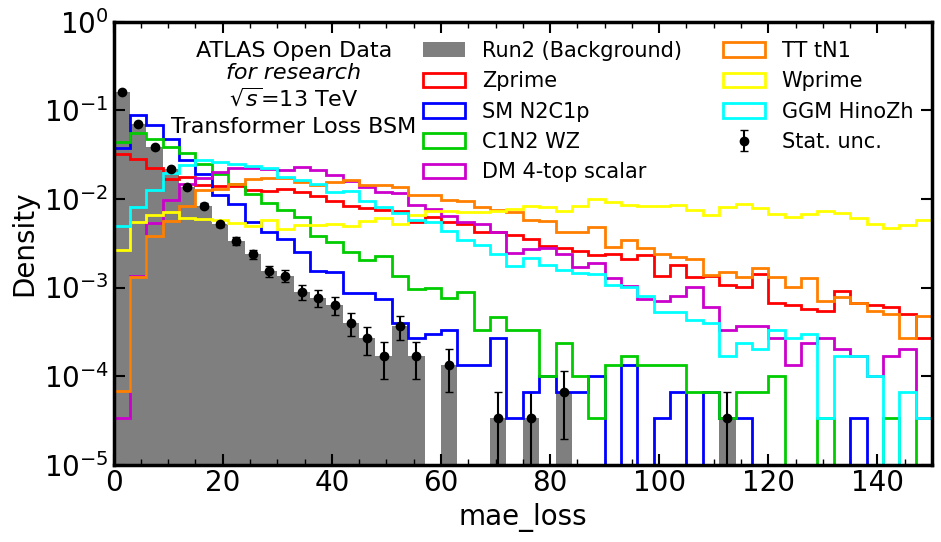

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator

# Assign dataframes from losses_dfs
run2_df = losses_dfs['run2']

# New signal datasets
zprime_df = losses_dfs['NNPDF23LO_Zprime3000_tt_0']
smn2c1p_df = losses_dfs['SM_N2C1p_105_100_2L2MET75_0']
c1n2wz_df = losses_dfs['LO_C1N2_WZ_500p0_100p0_3L_2L7_0']
dm4top_df = losses_dfs['LO_DM_4topscalar_p1000_c1_nonallhad_0']
ttn1_df = losses_dfs['LO_TT_tN1_1200_200_0']
wprime_df = losses_dfs['NNPDF23LO_Wprime_taunu_SSM3000_0']
ggm_df = losses_dfs['LO_C1N2N1_GGMHinoZh50_800_noFilter_0']

# Combine into data dictionary
data_new = {
    'data': run2_df,
    'Zprime': zprime_df,
    'SM N2C1p': smn2c1p_df,
    'C1N2 WZ': c1n2wz_df,
    'DM 4-top scalar': dm4top_df,
    'TT tN1': ttn1_df,
    'Wprime': wprime_df,
    'GGM HinoZh': ggm_df,
}

# Vibrant colors for the new signal samples
samples_to_plot_new = {
    'Zprime': {'color': '#FF0000'},          # bright red
    'SM N2C1p': {'color': '#0000FF'},        # bright blue
    'C1N2 WZ': {'color': '#00CC00'},         # bright green
    'DM 4-top scalar': {'color': '#CC00CC'}, # bright magenta
    'TT tN1': {'color': '#FF7F00'},           # vivid orange
    'Wprime': {'color': '#FFFF00'},           # bright yellow
    'GGM HinoZh': {'color': '#00FFFF'},       # cyan
}

def plot_loss_data(data, samples_to_plot, x_variable='mae_loss', region_label='Transformer Loss'):
    bin_edges = np.linspace(0, 150, 51)
    
    plt.figure(figsize=(10,6))
    main_axes = plt.gca()
    
    # Background histogram + error bars
    counts, edges = np.histogram(data['data'][x_variable], bins=bin_edges)
    bin_centers = 0.5 * (edges[1:] + edges[:-1])
    bin_widths = np.diff(edges)
    total = counts.sum()
    
    density = counts / (total * bin_widths)  # normalized counts for density
    errors = np.sqrt(counts) / (total * bin_widths)  # Poisson errors for density
    
    main_axes.hist(data['data'][x_variable],
                   bins=bin_edges,
                   density=True,
                   color='black',
                   alpha=0.5,
                   label='Run2 (Background)',
                   log=True)
    
    main_axes.errorbar(bin_centers, density, yerr=errors,
                       fmt='o', color='black', markersize=6,
                       capsize=3, label='Stat. unc.')

    # Plot each signal sample as step histogram
    for s in samples_to_plot:
        main_axes.hist(data[s][x_variable],
                       bins=bin_edges,
                       density=True,
                       histtype='step',
                       color=samples_to_plot[s]['color'],
                       linewidth=2,
                       label=s)

    # Axis labels and limits
    main_axes.set_xlim(bin_edges[0], bin_edges[-1])
    main_axes.set_xlabel(x_variable, fontsize=20)
    main_axes.set_ylabel('Density', fontsize=20)
    main_axes.xaxis.set_minor_locator(AutoMinorLocator())
    main_axes.yaxis.set_minor_locator(AutoMinorLocator())
    main_axes.tick_params(which='both', direction='in', top=True, right=True, length=8, width=1.5)
    main_axes.tick_params(which='minor', length=4, width=1)
    
    # Log scale and locator for y-axis
    main_axes.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    
    main_axes.tick_params(axis='both', which='major', labelsize=20)
    main_axes.tick_params(axis='both', which='minor', labelsize=20)
    main_axes.set_ylim(1e-5, 1)

    # Text block
    plt.text(0.22, 0.92, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=16, ha='center')
    plt.text(0.22, 0.87, 'for research', transform=main_axes.transAxes, fontsize=16, style='italic', ha='center')
    plt.text(0.22, 0.81, r'$\sqrt{s}$=13 TeV', transform=main_axes.transAxes, fontsize=16, ha='center')
    plt.text(0.22, 0.75, region_label, transform=main_axes.transAxes, fontsize=16, ha='center')

    # Legend
    main_axes.legend(ncol=2, frameon=False, fontsize=15)

    plt.tight_layout()
    plt.savefig('transformerloss_2.png')
    plt.show()

# Call the plotting function with new vibrant colors
plot_loss_data(data_new, samples_to_plot_new, x_variable='mae_loss', region_label='Transformer Loss BSM')


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Convert DataFrames to NumPy arrays
jet3_recn = reconstructed_x['Wenu_maxHTpTV2_CFilterBVeto_0'][:5000].to_numpy()
jet3_X = x_test['Wenu_maxHTpTV2_CFilterBVeto_0'][:5000].to_numpy()

# Combine datasets into a list
datasets = [
    jet3_recn,
    jet3_X
]

# Initialize min and max values
min_values = []
max_values = []
min_cols = min(data.shape[1] for data in datasets)

# Loop through each feature index and calculate min and max values
for i in range(min_cols):
    min_val = min(np.min(data[:, i]) for data in datasets)
    max_val = max(np.max(data[:, i]) for data in datasets)
    min_values.append(min_val)
    max_values.append(max_val)

# Function to plot histograms with dots and error bars
def plot_histogram_with_dots_and_errors(real_data, decoded_data, min_value, max_value, xlabel, title, subplot_index, bins=100):
    range_values = (min_value, max_value)

    real_hist, bin_edges = np.histogram(real_data, bins=bins, range=range_values, density=False)
    decoded_hist, _ = np.histogram(decoded_data, bins=bins, range=range_values, density=False)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Calculate error as sqrt(counts) for real data
    real_errors = np.sqrt(real_hist)

    plt.subplot(88, 1, subplot_index)  # This still seems excessive—see note below
    plt.scatter(bin_centers, decoded_hist, color='red', label='Reconstructed Data', marker='o')
    plt.errorbar(bin_centers, real_hist, yerr=real_errors, fmt='^', color='blue', label='Input Data', linestyle='None')

    plt.xscale('linear')
    plt.yscale('log')  # Logarithmic scale for y-axis

    plt.xlabel(xlabel, fontsize=8, fontweight='bold')
    plt.ylabel('Events', fontsize=8, fontweight='bold')
    plt.title(title, fontsize=10, fontweight='bold')

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    if subplot_index <= 4:  # Show legend only on the first few
        plt.legend(fontsize=6)

# Create subplots
plt.figure(figsize=(20, 480))  # Adjust size to fit all subplots

# Replace this with your actual feature/column names
branches = reconstructed_x['run2'].columns.tolist()

# Plot for each variable
total_vars = min_cols
for i in range(total_vars):
    real_data = jet3_X[:, i]
    decoded_data = jet3_recn[:, i]
    xlabel = branches[i]
    title = branches[i]
    plot_histogram_with_dots_and_errors(real_data, decoded_data, min_values[i], max_values[i], xlabel, title, i + 1)

plt.tight_layout()
plt.savefig("histograms_84_variables.png")
plt.show()


### Filtering and Saving High Reconstruction Loss Events

This code snippet performs the following tasks:

- Loads ROOT data from a ROOT file using `ROOT.RDataFrame`.
- Creates a TensorFlow dataset for test events with no validation split and batch size of 512.
- Iterates over batches in the test dataset:
  - Passes input features through a pretrained transformer model to get reconstructed outputs.
  - Computes the reconstruction loss per feature and averages it per event.
  - Filters events where the reconstruction loss exceeds a set threshold (`loss_threshold = 60`).
- Collects corresponding target values, input features, and losses for high-loss events.
- Concatenates filtered data across all batches.
- Saves the filtered events to a CSV file (`high_loss_events.csv`) with added column for reconstruction loss.
- If no events exceed the threshold, prints a message indicating no such events found.

This process helps identify anomalous events in test data based on unusually high reconstruction loss.


In [17]:
import ROOT
tree_name = "myTree"
file_name_ = ['root://eosuser.cern.ch//eos/user/a/asradhak/SWAN_projects/ml_training/training/run2.root']

# Load the dataframe
rdf2 = ROOT.RDataFrame(tree_name, file_name_)
rdf2.Count().GetValue()


4172835

In [26]:
# Create TensorFlow dataset
ds_test_ = ROOT.TMVA.Experimental.CreateTFDatasets(
    rdf2,
    batch_size=512,
    chunk_size=100000,
    validation_split=0.0,  # No validation split, since this is test data
    shuffle=False,
    target=targets,
)

# We just need the features (inputs) for testing



In [30]:
loss_threshold = 60
filtered_events = []
for batch in ds_test_:
    X_test_, y_true = batch
    decoded, mask = loaded_transformer(X_test_, training=False)
    
    # Compute reconstruction loss comparing predicted (decoded) to true (y_true)
    loss = RecoProb_(X_test_, decoded, mask)  # shape (batch_size, num_features)
    
    # Convert tensors to numpy
    loss_np = loss.numpy()
    y_true_np = y_true.numpy()  # targets to save
    X_test_np = X_test_.numpy()
    # Compute scalar loss per event (e.g., mean across features)
    loss_per_event = loss_np.mean(axis=1)
    
    # Find events where loss > threshold
    high_loss_mask = loss_per_event > loss_threshold
    
    # Filter corresponding targets and losses for those events
    filtered_targets1 = y_true_np[high_loss_mask]
    filtered_targets2 = X_test_np[high_loss_mask]



    
    filtered_losses = loss_per_event[high_loss_mask].reshape(-1, 1)  # shape (N,1)
    
    # Concatenate filtered targets and losses
    filtered_with_loss = np.hstack((filtered_targets1,filtered_targets2, filtered_losses))
    
    filtered_events.append(filtered_with_loss)

if filtered_events:
    filtered_events_all = np.concatenate(filtered_events, axis=0)
    
    # Create new column list adding the loss column name
    columns_with_loss = targets + branches + ["reconstruction_loss"]
    
    # Save to CSV
    df_filtered = pd.DataFrame(filtered_events_all, columns=columns_with_loss)
    df_filtered.to_csv("high_loss_events.csv", index=False, mode = "w")
else:
    print("No events found with loss above the threshold.")

2025-07-03 21:35:59.445687: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Sorting and Selecting Top High-Loss Events

This code snippet performs the following steps:

- Loads the previously saved CSV file `high_loss_events.csv` containing events filtered by high reconstruction loss.
- Sorts the DataFrame in descending order by the `reconstruction_loss` column to prioritize the most anomalous events.
- Defines a list of specific variables (`selected_columns`) to retain for further analysis.
- Filters the `selected_columns` list to ensure only columns present in the DataFrame are selected.
- Selects the top 200 events based on the sorted order and retains only the specified columns.
- Prints the shape of the resulting DataFrame to confirm the number of selected rows and columns.

This procedure helps focus on the most anomalous events and relevant variables for downstream analysis.


In [31]:
import pandas as pd

# Load the CSV file
df_ = pd.read_csv("high_loss_events.csv")

# Sort by reconstruction loss descending (highest anomalous score first)
df_sorted = df_.sort_values(by="reconstruction_loss", ascending=False)

# Select variables (columns) you want in the final DataFrame
# Replace these with the actual variable names you want to keep
selected_columns = ['mj1j3', 'mj1j4', 'mj2j3', 'mj2j4', 'mj3j4', 'Nbjets', 'mb1b2',
                    'delta_Rj1j3', 'delta_Rj1j4', 'delta_Rj2j4', 'delta_Rj3j4',
                    'MT', "Mgg", "Mggg", "Mgggg", "Mll", "Mlll", "Mllll", "MTgg",
                    "mj1l", "mjjj", "mjjll",'Nelectrons', 'Njets', 'Nmuons', 'Nphotons',
                    'Ngamma', "reconstruction_loss"]

# Make sure the selected columns exist in the DataFrame
selected_columns = [col for col in selected_columns if col in df_sorted.columns]

df = df_sorted[branches][:200]

# Show the top rows
print(df.shape)


(130, 52)


### Clustering Mixed-Type Data Using Gower Distance, UMAP, and HDBSCAN

This code performs clustering on a dataset with mixed data types by following these steps:

1. **Load Data:** Load your dataset into a pandas DataFrame `df`.
2. **Gower Distance:** Calculate the Gower distance matrix, which is suitable for mixed numerical and categorical data.
3. **UMAP:** Use UMAP with the precomputed Gower distance matrix to reduce data dimensionality to 2D.
4. **HDBSCAN:** Cluster the UMAP embeddings with HDBSCAN to identify clusters.
5. **Attach Labels:** Add the resulting cluster labels to the original DataFrame.
6. **Visualization:** Plot the 2D UMAP embedding colored by cluster assignment.

This approach is useful when you have mixed data types and want a robust clustering method that combines distance metrics designed for mixed data (Gower), nonlinear dimensionality reduction (UMAP), and density-based clustering (HDBSCAN).


In [ ]:

import pandas as pd
import numpy as np
import gower
import umap.umap_ as umap
import hdbscan

# Step 1: Load your DataFrame
# df = pd.read_csv("your_data.csv")  # Assume you already have `df`

# Step 2: Gower distance for mixed types
gower_dist = gower.gower_matrix(df)

# Step 3: UMAP for dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    metric='precomputed',
    random_state=42
)
embedding = reducer.fit_transform(gower_dist)

# Step 4: HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(embedding)

# Step 5: Attach cluster labels to original data
df['cluster'] = labels

# Optional: inspect results
print(df['cluster'].value_counts())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette='tab10')
plt.title("UMAP + HDBSCAN Clustering")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.show()


### Post-Clustering Profiling: Identifying Key Variables Separating Clusters

This code helps characterize each cluster by finding which variables best distinguish it from others:

- **Effect Size for Numeric Variables:** Uses Cohen's d to measure the standardized mean difference between the cluster and all other data.
- **Association for Categorical Variables:** Uses Cramér's V (based on chi-square test) to measure the strength of association between cluster membership and categorical features.
- **Ranking Features:** For each cluster (excluding noise), numeric and categorical variables are ranked by their effect sizes or association values.
- **Visualization Examples:** Optional plots to visualize the top numeric and categorical features for a selected cluster, using boxplots and count plots respectively.

This profiling step is crucial for interpreting clusters by highlighting the variables most relevant to cluster separation.


In [ ]:


# --- (5) Post-clustering profiling ---
# Identify which variables best separate each cluster from the others.

# Helper function: compute Cohen's d (effect size for mean difference).
def cohen_d(x1, x2):
    # Remove NaNs
    x1 = np.array(x1.dropna())
    x2 = np.array(x2.dropna())
    n1, n2 = len(x1), len(x2)
    if n1 < 2 or n2 < 2:
        return 0.0  # not enough data
    # Compute means and std dev
    m1, m2 = x1.mean(), x2.mean()
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    # Pooled standard deviation
    pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    if pooled == 0:
        return 0.0
    return (m1 - m2) / pooled

# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('cluster')
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Prepare a dictionary to hold ranked features per cluster
cluster_rankings = {}

for clust in sorted(df['cluster'].unique()):
    if clust == -1:
        continue  # skip noise
    # Boolean mask for current cluster vs others
    mask = (df['cluster'] == clust)
    mask_other = ~mask
    size_clust = mask.sum()
    size_rest = mask_other.sum()
    if size_clust < 2:
        continue  # skip small clusters

    num_scores = []  # (variable, score) for numeric
    cat_scores = []  # (variable, score) for categorical

    # Numeric variables: use Cohen's d
    for col in numeric_cols:
        x1 = df.loc[mask, col]
        x2 = df.loc[mask_other, col]
        d = cohen_d(x1, x2)
        num_scores.append((col, abs(d)))
    # Sort numeric by descending |d|
    num_scores.sort(key=lambda x: x[1], reverse=True)

    # Categorical variables: use Cramér's V from chi-square
    for col in categorical_cols:
        # Build contingency table: (cluster membership) x (category)
        cont = pd.crosstab(df[col], mask)  # index=categories, columns=False/True for other/cluster
        if cont.shape[0] < 2:
            continue  # no variation in category
        # Perform chi-square test
        chi2, p, _, _ = chi2_contingency(cont.values.T)
        N = cont.values.sum()
        # Cramer's V (for 2xk table, it's sqrt(chi2/N))
        V = np.sqrt(chi2 / N) if N > 0 else 0
        cat_scores.append((col, V))
    # Sort categorical by descending V
    cat_scores.sort(key=lambda x: x[1], reverse=True)

    # Store top variables (top 5 of each type, for example)
    cluster_rankings[clust] = {
        'numeric': num_scores[:5],
        'categorical': cat_scores[:5]
    }

# Print ranked variables for each cluster
for clust, ranks in cluster_rankings.items():
    print(f"\nCluster {clust}:")
    print("  Top numeric variables (Cohen's d):")
    for var, score in ranks['numeric']:
        print(f"    {var}: d = {score:.2f}")
    print("  Top categorical variables (Cramér's V):")
    for var, score in ranks['categorical']:
        print(f"    {var}: V = {score:.2f}")

# --- (6) Example visualizations (optional) ---
# For illustration, plot the top feature for cluster 0 if desired:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: boxplot of top numeric feature for cluster 0 vs others
if 0 in cluster_rankings:
    top_num_var = cluster_rankings[0]['numeric'][0][0]
    plt.figure(figsize=(4,3))
    sns.boxplot(x=(df['cluster']==0).astype(int), y=df[top_num_var],
                palette=["#bbbbbb","#ee3333"])
    plt.xticks([0,1], ["Other", "Cluster 0"])
    plt.title(f"Cluster 0 vs Others for '{top_num_var}'")
    plt.ylabel(top_num_var)
    plt.show()

# Example: bar plot of top categorical feature for cluster 0
if 0 in cluster_rankings and cluster_rankings[0]['categorical']:
    top_cat_var = cluster_rankings[0]['categorical'][0][0]
    plt.figure(figsize=(4,3))
    # Count frequencies in cluster vs others
    df_plot = df.copy()
    df_plot['in_cluster0'] = np.where(df_plot['cluster']==0, 'Cluster 0', 'Others')
    sns.countplot(x=top_cat_var, hue='in_cluster0', data=df_plot)
    plt.title(f"Category counts of '{top_cat_var}'")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.legend(title="")
    plt.show()


In [ ]:
### Visualizing Mass-Related Variables Across Clusters

This code creates density histograms for a set of mass-related variables, comparing their distributions across different clusters:

- **Setup:** Configures plotting style and figure size for clear visualization.
- **Variables:** Focuses on specific mass variables relevant to the dataset.
- **Cluster-wise Plots:** For each mass variable, overlays histograms for each cluster using different colors.
- **Axis Limits:** Custom x-axis ranges improve readability tailored to each variable’s typical values.
- **Output:** Displays plots and saves the full figure as "cLUSTER.png".

This visualization helps to understand how mass-related features vary between clusters, supporting cluster interpretation.


In [ ]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Set plotting style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 20))

# List of the mass-related variables to plot
mass_columns = [
    "Mgg", "Mggg", "Mgggg",
    "Mll", "Mlll", "Mllll",
    "MT", "MTgg",
    "mj1j2", "mj1l", "mjjj", "mjjll"
]

# Define custom x-axis limits for each variable
x_ranges = {
    "Mgg": (0, 200),
    "Mggg": (0, 300),
    "Mgggg": (0, 400),
    "Mll": (0, 25),
    "Mlll": (0, 150),
    "Mllll": (0, 150),
    "MT": (0, 200),
    "MTgg": (0, 200),
    "mj1j2": (0, 1500),
    "mj1l": (0, 600),
    "mjjj": (0, 1000),
    "mjjll": (0, 1000)
}

# Unique clusters
clusters = sorted(df['cluster'].unique())
palette = sns.color_palette("tab10", len(clusters))

for i, col in enumerate(mass_columns, 1):
    plt.subplot(4, 3, i)

    for cluster_id, color in zip(clusters, palette):
        cluster_data = df.loc[(df['cluster'] == cluster_id) &
                              (df[col] != -99) &
                              (df[col] <= 2000), col]

        sns.histplot(cluster_data, bins=100, kde=True, label=f"Cluster {cluster_id}",
                     color=color, element="step", stat="density", common_norm=False)

    plt.title(col)
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Density")
    plt.xlim(x_ranges.get(col, (0, 500)))  # fallback to (0, 500) if not specified
    plt.legend()

plt.tight_layout()
plt.savefig("cLUSTER.png")
plt.show()

